In [2]:
import sys, os, json
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.baseline import baseline_models, run_cv

sns.set_theme(style="whitegrid")

X_train = pd.read_parquet("../data/processed/X_train.parquet")
y_train = pd.read_parquet("../data/processed/y_train.parquet")["_MICHD"]

sel = json.load(open("../reports/selected_features.json"))
feature_sets = {"minimal15": sel["minimal"], "full29": sel["full"]}
print({k: len(v) for k, v in feature_sets.items()})       # {'minimal15': 15, 'full29': 29}

# one fixed 30k stratified subsample, shared by all six models
_, X_sub, _, y_sub = train_test_split(X_train, y_train, test_size=30000,
                                      stratify=y_train, random_state=42)
print(X_sub.shape, round(y_sub.mean(), 4))

{'minimal15': 15, 'full29': 29}
(30000, 29) 0.0936


In [3]:
os.makedirs("../reports", exist_ok=True)
rows = []
for fs_name, feats in feature_sets.items():
    for name, model in baseline_models().items():
        row = run_cv(name, model, feats, X_sub, y_sub)
        row["feature_set"] = fs_name
        row["train_rows"] = len(X_sub)
        rows.append(row)
        print(f"{fs_name:9s} {name:7s} AUC={row['roc_auc_mean']:.3f}  "
              f"PR-AUC={row['pr_auc_mean']:.3f}  recall@0.5={row['recall_mean']:.3f}  "
              f"({row['fit_seconds']:.0f}s)")

results_30k = pd.DataFrame(rows)
results_30k.to_csv("../reports/baseline_results_30k.csv", index=False)

minimal15 logreg  AUC=0.829  PR-AUC=0.345  recall@0.5=0.095  (3s)
minimal15 knn     AUC=0.793  PR-AUC=0.278  recall@0.5=0.034  (2s)
minimal15 svm     AUC=0.668  PR-AUC=0.254  recall@0.5=0.008  (52s)
minimal15 dtree   AUC=0.805  PR-AUC=0.302  recall@0.5=0.072  (0s)
minimal15 rf      AUC=0.829  PR-AUC=0.342  recall@0.5=0.020  (4s)
minimal15 xgb     AUC=0.828  PR-AUC=0.335  recall@0.5=0.099  (2s)
full29    logreg  AUC=0.830  PR-AUC=0.343  recall@0.5=0.097  (1s)
full29    knn     AUC=0.785  PR-AUC=0.269  recall@0.5=0.028  (3s)
full29    svm     AUC=0.706  PR-AUC=0.260  recall@0.5=0.004  (94s)
full29    dtree   AUC=0.797  PR-AUC=0.294  recall@0.5=0.076  (0s)
full29    rf      AUC=0.828  PR-AUC=0.342  recall@0.5=0.013  (4s)
full29    xgb     AUC=0.829  PR-AUC=0.332  recall@0.5=0.096  (3s)


In [5]:
order = ["logreg", "knn", "svm", "dtree", "rf", "xgb"]
show = ["roc_auc", "pr_auc", "recall", "specificity"]

def fmt(m):
    return results_30k[f"{m}_mean"].round(3).astype(str) + " ± " + results_30k[f"{m}_std"].round(3).astype(str)

tbl = results_30k[["model", "feature_set"]].copy()
for m in show:
    tbl[m] = fmt(m)
tbl = tbl.pivot(index="model", columns="feature_set", values=show).loc[order]
tbl

roc_auc                        pr_auc                 \
feature_set         full29      minimal15         full29      minimal15   
model                                                                     
logreg        0.83 ± 0.004  0.829 ± 0.004  0.343 ± 0.012  0.345 ± 0.014   
knn          0.785 ± 0.003  0.793 ± 0.008  0.269 ± 0.009  0.278 ± 0.012   
svm          0.706 ± 0.013  0.668 ± 0.012   0.26 ± 0.012  0.254 ± 0.011   
dtree        0.797 ± 0.004  0.805 ± 0.003  0.294 ± 0.015  0.302 ± 0.013   
rf           0.828 ± 0.002  0.829 ± 0.002  0.342 ± 0.015  0.342 ± 0.018   
xgb          0.829 ± 0.002  0.828 ± 0.004  0.332 ± 0.012  0.335 ± 0.015   

                    recall                   specificity                 
feature_set         full29      minimal15         full29      minimal15  
model                                                                    
logreg       0.097 ± 0.014  0.095 ± 0.009  0.991 ± 0.001  0.991 ± 0.001  
knn          0.028 ± 0.004  0.034 ± 0.003  0.998 ± 0.001  0.996 ± 0.001  
svm          0.004 ± 0.002  0.008 ± 0.003      1.0 ± 0.0      1.0 ± 0.0  
dtree        0.076 ± 0.015  0.072 ± 0.012  0.992 ± 0.001  0.991 ± 0.002  
rf           0.013 ± 0.004   0.02 ± 0.008    0.999 ± 0.0    0.999 ± 0.0  
xgb          0.096 ± 0.012  0.099 ± 0.015     0.99 ± 0.0  0.992 ± 0.001

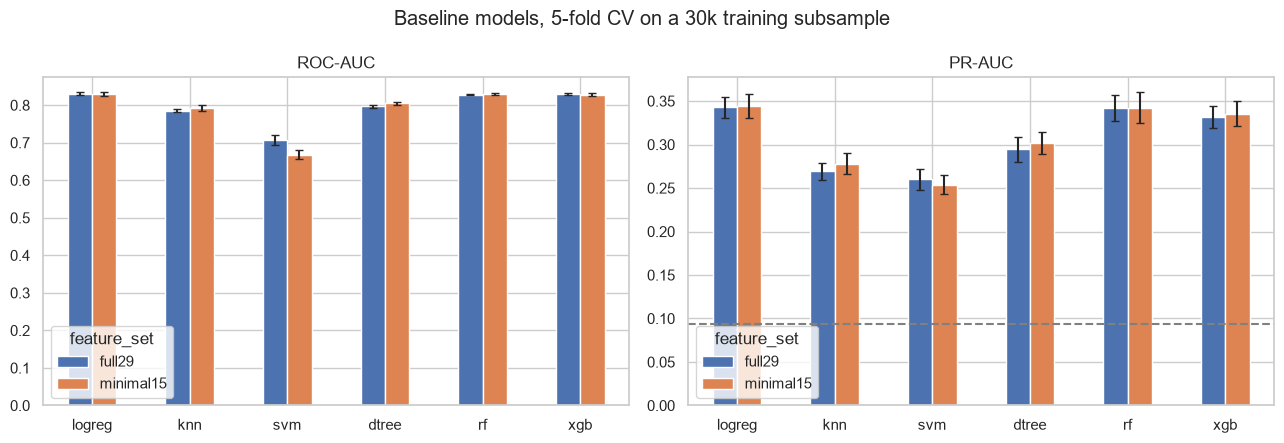

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, m in zip(axes, ["roc_auc", "pr_auc"]):
    mean = results_30k.pivot(index="model", columns="feature_set", values=f"{m}_mean").loc[order]
    std = results_30k.pivot(index="model", columns="feature_set", values=f"{m}_std").loc[order]
    mean.plot(kind="bar", yerr=std, ax=ax, capsize=3, rot=0)
    ax.set_title(m.replace("_", "-").upper())
    ax.set_xlabel("")
axes[1].axhline(y_sub.mean(), ls="--", color="grey")      # PR-AUC of a random model
plt.suptitle("Baseline models, 5-fold CV on a 30k training subsample")
plt.tight_layout()
plt.savefig("../reports/figures/08_baseline_30k.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
rows = []
for fs_name, feats in feature_sets.items():
    for name in ["logreg", "dtree", "xgb", "rf"]:
        row = run_cv(name, baseline_models()[name], feats, X_train, y_train)
        row["feature_set"] = fs_name
        row["train_rows"] = len(X_train)
        rows.append(row)
        print(f"{fs_name:9s} {name:7s} AUC={row['roc_auc_mean']:.3f}  "
              f"PR-AUC={row['pr_auc_mean']:.3f}  ({row['fit_seconds']:.0f}s)")

results_full = pd.DataFrame(rows)
results_full.to_csv("../reports/baseline_results_full_train.csv", index=False)

minimal15 logreg  AUC=0.828  PR-AUC=0.337  (4s)
minimal15 dtree   AUC=0.820  PR-AUC=0.319  (4s)
minimal15 xgb     AUC=0.831  PR-AUC=0.341  (9s)
minimal15 rf      AUC=0.829  PR-AUC=0.338  (91s)
full29    logreg  AUC=0.830  PR-AUC=0.341  (7s)
full29    dtree   AUC=0.820  PR-AUC=0.316  (8s)
full29    xgb     AUC=0.833  PR-AUC=0.346  (24s)
full29    rf      AUC=0.831  PR-AUC=0.342  (135s)


In [8]:
both = pd.concat([results_30k.assign(data="30k"), results_full.assign(data="full")])
both = both[both.model.isin(["logreg", "dtree", "xgb", "rf"])]
both.pivot_table(index=["feature_set", "model"], columns="data",
                 values=["roc_auc_mean", "pr_auc_mean"]).round(3)

pr_auc_mean        roc_auc_mean       
data                       30k   full          30k   full
feature_set model                                        
full29      dtree        0.294  0.316        0.797  0.820
            logreg       0.343  0.341        0.830  0.830
            rf           0.342  0.342        0.828  0.831
            xgb          0.332  0.346        0.829  0.833
minimal15   dtree        0.302  0.319        0.805  0.820
            logreg       0.345  0.337        0.829  0.828
            rf           0.342  0.338        0.829  0.829
            xgb          0.335  0.341        0.828  0.831

## Baseline findings

**Performance plateau.** Logistic regression, Random Forest and XGBoost reach ROC-AUC ≈ 0.83 and PR-AUC ≈ 0.34 under 5-fold CV (random-classifier PR-AUC = 0.094, so roughly 3.6× lift), and are statistically indistinguishable (differences ≤ 0.002 against fold standard deviations of 0.002–0.004). A linear model matching gradient boosting suggests mostly additive structure and an information ceiling set by the available survey variables, not by model complexity.

**Weaker models.** KNN (ROC-AUC 0.79), a depth-8 decision tree (0.80–0.82) and an untuned RBF SVM (0.67–0.71, high variance) trailed the top group.

**Feature sets.** The 15-feature minimal set matched the 29-feature set within noise (≤ 0.003 AUC), indicating 15 survey questions retain nearly all usable signal.

**Data size.** Training on the full 362k rows instead of a 30k subsample changed ROC-AUC by ≤ 0.004 for logistic regression, Random Forest and XGBoost (the decision tree gained 0.015–0.023), so subsampling is acceptable for SVM/KNN comparison and tuning.

**Class imbalance.** With no imbalance handling, recall at the default 0.5 threshold was only 1–10% at ≥ 99% specificity: models almost never predict the minority class despite good ranking ability (AUC). This motivates class weighting and threshold selection.